In [16]:
import torch
import torch.nn.functional as F
import torch.nn as nn
# import torch.optim as optim
# import torch_optimizer as optim
import torch.nn.init as init
import adabound
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split

from sys import stdout
from tqdm import tqdm
from tqdm import trange
import seaborn as sns

import time
from datetime import datetime as dt

In [17]:
df = pd.read_csv('C:/Users/KIST3/Desktop/13C/testdata.csv')
# df

In [18]:
# y = df[['x', 'N', 'z']]
# # y


y = df[['Xtau', 'XN', 'Ztau', 'ZN']]
y

,Xtau,XN,Ztau,ZN
0,2.695078,15.0,1.783756,15.0
1,2.943674,17.0,2.348274,13.0
2,4.108506,9.0,2.670844,13.0
3,1.740023,17.0,1.000523,1.0
4,1.471003,7.0,0.891889,15.0
...,...,...,...,...
41969,0.321459,19.0,0.172630,32.0
41970,4.826822,26.0,2.482350,1.0
41971,4.820681,50.0,2.426428,38.0
41972,4.067152,26.0,2.642715,13.0


In [22]:
X = df[['Al', 'Ap']]


# X

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.05, random_state=100)

In [24]:
X_train

,Al,Ap
2483,3.548632,1.149127
28689,4.994051,1.767184
7753,0.490845,0.426321
383,1.360544,1.262187
39618,0.843145,1.320650
...,...,...
16304,0.376277,0.428329
79,4.727607,1.693828
12119,2.768744,1.227849
14147,3.288457,1.086054


In [25]:
Xdata = list(np.array(X_train.values.tolist()))
# Xdata

In [26]:
ydata = list(np.array(y_train.values.tolist()))
# print(ydata)

In [27]:
torch.manual_seed(1)

In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [29]:
x = torch.FloatTensor(Xdata).to(device)
y = torch.FloatTensor(ydata).to(device)

In [30]:
num_data = 39875

num_epoch = 2000000

  0%|          | 0/2000000 [00:00<?, ?it/s]C:\Users\KIST3\AppData\Roaming\Python\Python37\site-packages\adabound\adabound.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Triggered internally at  C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\python_arg_parser.cpp:1174.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
  0%|          | 3/2000000 [00:03<549:01:11,  1.01it/s] 

Minimum loss: 10

  1%|          | 10003/2000000 [12:02<41:09:37, 13.43it/s]

Minimum loss: tensor(4.9062, device='cuda:0', grad_fn=<L1LossBackward0>)

  1%|          | 20003/2000000 [24:13<40:17:47, 13.65it/s]

...

Minimum loss: tensor(0.0704, device='cuda:0', grad_fn=<L1LossBackward0>)

100%|█████████▉| 1999999/2000000 [36:48:09<00:00, 15.16it/s]

tensor(0.1393, device='cuda:0')


100%|██████████| 2000000/2000000 [36:48:09<00:00, 15.10it/s]

[Parameter containing:
tensor([[-5.9126e-01, -1.2534e-02],
        [-1.3676e-01, -1.6133e-01],
        [-9.3465e-01,  4.6391e+00],
        [ 8.8506e-01,  1.8000e-01],
        [ 2.0624e+00, -2.9051e+00],
        [-2.6694e-01,  1.3405e-01],
        [-7.3360e+00,  3.3165e+00],
        [-8.8615e-02,  1.1141e+01],
        [ 1.9242e+00, -1.0188e+00],
        [-1.2223e+00,  5.0106e+00],
        [ 7.4221e+00, -4.6768e+00],
        [-1.4201e-01, -3.7769e-01],
        [-7.8543e-02,  1.0278e+01],
        [-3.1637e-02, -5.4657e+00],
        [-3.7866e+00, -2.3595e-01],
        [-2.4293e+00,  1.2364e+00],
        [-1.3031e-01,  1.6368e+01],
        [-3.3399e+00,  1.3310e+01],
        [ 3.5515e-01,  3.6810e+00],
        [ 1.4135e+00, -3.4980e+00],
        [-6.0869e-01, -1.5985e-01],
        [-1.0783e-01,  1.4159e+01],
        [-6.9875e-01, -6.7158e-01],
        [-1.3594e-01, -1.9299e+00],
        [-1.6269e+00,  3.8237e-01],
        [-7.1010e-02, -1.1994e+01],
        [-1.5525e+00,  2.5762e+00],
     

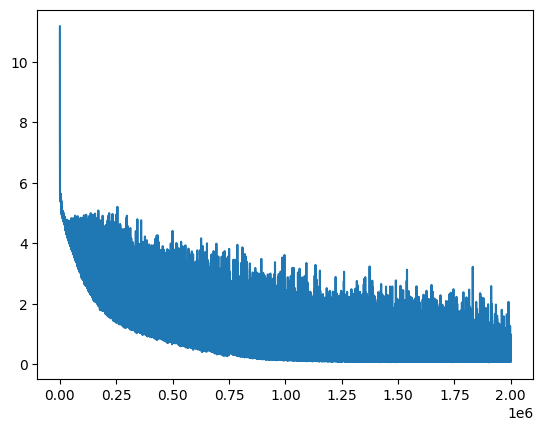

In [31]:
model = nn.Sequential(

    nn.Linear(2,500),

    nn.ReLU(),

    nn.Linear(500,500),

    nn.ReLU(),

    nn.Linear(500,500),

    nn.ReLU(),
    
    nn.Linear(500,500),

    nn.ReLU(),
    
    nn.Linear(500,500),

    nn.ReLU(),
        
    nn.Linear(500,500),

    nn.ReLU(),
            
    nn.Linear(500,500),

    nn.ReLU(),
            
    nn.Linear(500,500),

    nn.ReLU(),
            
    nn.Linear(500,500),

    nn.ReLU(),
            
    nn.Linear(500,500),

    nn.ReLU(),
            
    nn.Linear(500,500),

    nn.ReLU(),
              
    nn.Linear(500,500),

    nn.ReLU(),
              
    nn.Linear(500,500),

    nn.ReLU(),
    
    nn.Linear(500,2000),

    nn.ReLU(),

    nn.Linear(2000,4)

).to(device)

#ReLU라는 Activation Function을 사용하여, 4개의 Linear Layer로 모델 구현

# Input layer에 1개씩 데이터가 들어가므로 nn.Linear(1,2)이며, 최종적으로 1개의 값이 나와야하기에 Output Layer는 nn.Linear(4,1)

 

loss_func = nn.L1Loss().to(device)

# optimizer = optim.SGD(model.parameters(),lr = 0.0002)

# optimizer = adabound.AdaBound(model.parameters(), lr=0.935 * 1e-4, final_lr=0.05758)  #Loss: 0.0537

# optimizer = adabound.AdaBound(model.parameters(), lr=0.435 * 1e-3, final_lr=0.05558)

optimizer = adabound.AdaBound(model.parameters(), lr=0.935 * 1e-4, final_lr=0.04958)  #Loss: 0.0537

loss_array = []

minloss = 10

for i in tqdm(range(num_epoch)) : 

    optimizer.zero_grad()

    output = model(x)

    loss = loss_func(output,y)

    loss.backward()

    optimizer.step()

    if(loss < minloss):
       minloss = loss

    loss_array.append(loss)

    if(i%10000 == 0):
      # print("Case "+ str(i) + ", Loss: " + str(loss.data))
      stdout.write("Minimum loss: " + str(minloss))

    if i == num_epoch - 1:

        print(loss.data)

        param_list = list(model.parameters())

        #최종 학습된 마지막 결과물의 Parameter 저장

        print(param_list)

loss_array = torch.tensor(loss_array)

loss_array.detach().numpy()

plt.plot(loss_array)

plt.show()

#Loss(y_predicted - y_real)값이 어떻게 변하는지 그래프로 도식화

In [ ]:
# # 임의의 입력 [73, 80, 75]를 선언
# new_var =  torch.FloatTensor([[4.493041, 0.5427]]).to(device)
# # 입력한 값 [73, 80, 75]에 대해서 예측값 y를 리턴받아서 pred_y에 저장
# pred_y = model(new_var) 
# print("훈련 후 예측값 :", pred_y) 

In [32]:
date = dt.now()
printdate = date.strftime('%Y%m%d_%H%M%S')
print(date)
torch.save(model, "C:/Users/KIST3/Desktop/13C/model/CNN_MODEL_" + printdate + ".h5")

2023-03-16 22:17:28.989106


In [ ]:
# model = TheModelClass(*args, **kwargs)
# model.load_state_dict(torch.load(PATH))
# model.eval()

In [49]:
X_input = list(np.array(X_valid.values.tolist()))
new_var =  torch.FloatTensor(X_input).to(device)
y_input = model(new_var)
y_input = np.array(y_input.tolist())
y_input

array([[ 2.93859291, 12.96946526,  2.30376005, 12.81040001],
       [ 3.69096518, 26.00259399,  1.94844937,  1.01970816],
       [ 4.01422024, 13.77094364,  2.90137935, 15.90056801],
       ...,
       [ 4.01761341, 31.41200256,  2.24298835,  5.62506104],
       [ 3.42637491, 12.93083572,  2.45123363, 13.08348465],
       [ 3.59711218, 26.01134491,  1.87451184,  0.99896955]])

In [50]:
y_output = np.array(y_valid.values.tolist())
y_output

array([[ 1.63047741,  9.        ,  1.19447016,  9.        ],
       [ 3.6744129 , 26.        ,  2.38869768, 26.        ],
       [ 4.06106468,  9.        ,  2.95776639, 13.        ],
       ...,
       [ 4.06476278, 38.        ,  2.10376206,  1.        ],
       [ 2.7909962 , 13.        ,  1.61124423, 17.        ],
       [ 3.58276667,  9.        ,  2.61976167,  9.        ]])

In [51]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# MAE
print("X tau MAE: " + str(mean_absolute_error(y_input[:, 0], y_output[:, 0])))
print("X N MAE: " + str(mean_absolute_error(y_input[:, 1], y_output[:, 1])))
print("Z tau MAE: " + str(mean_absolute_error(y_input[:, 2], y_output[:, 2])))
print("Z N MAE: " + str(mean_absolute_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#MSE
print("X tau MSE: " + str(mean_squared_error(y_input[:, 0], y_output[:, 0])))
print("X N MSE: " + str(mean_squared_error(y_input[:, 1], y_output[:, 1])))
print("Z tau MSE: " + str(mean_squared_error(y_input[:, 2], y_output[:, 2])))
print("Z N MSE: " + str(mean_squared_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#r2
print("X tau r2: " + str(r2_score(y_input[:, 0], y_output[:, 0])))
print("X N r2: " + str(r2_score(y_input[:, 1], y_output[:, 1])))
print("Z tau r2: " + str(r2_score(y_input[:, 2], y_output[:, 2])))
print("Z N r2: " + str(r2_score(y_input[:, 3], y_output[:, 3])))

X tau MAE: 0.346341927957479
X N MAE: 9.008438770972075
Z tau MAE: 0.35482270877514144
Z N MAE: 11.406804865459534
 
X tau MSE: 0.5885389305270126
X N MSE: 190.11537724308224
Z tau MSE: 0.33669039096383896
Z N MSE: 247.07031477889618
 
X tau r2: 0.6350255210760236
X N r2: -0.43788468949876513
Z tau r2: 0.5352981163989918
Z N r2: -0.7375114312898308


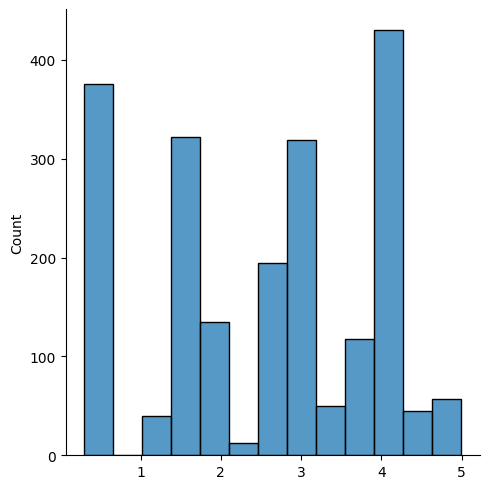

In [66]:
sns.displot(y_output[:, 0])

In [67]:
from toqito.channels import partial_trace
from qutip import *
from PIL import Image
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from scipy import linalg
import math
import matplotlib.pyplot as plt
from scipy import optimize
import random
from math import *
import pandas as pd
import time
from datetime import datetime as dt                         # 시간을 출력하기 위한 라이브러리  

def UO(B1,B2,a,D1,D2):
    i   = 1j
    gamma = 2*pi*2.8
    D     = 2870
    UA = np.array([[(B2**2+B1**2*cos(a))/(B1**2+B2**2), -i*B1*(e**(-i*D1))*sin(a)/sqrt(B1**2+B2**2), ((-1+cos(a))*B1*B2*(e**(-i*(D1-D2))))/(B1**2+B2**2)],
            [-i*B1*(e**(i*D1))*sin(a)/sqrt(B1**2+B2**2), cos(a), -i*B2*(e**(i*D2))*sin(a)/sqrt(B1**2+B2**2)],
            [((-1+cos(a))*B1*B2*e**(i*(D1-D2)))/(B1**2+B2**2), -i*B2*(e**(-i*D2))*sin(a)/sqrt(B1**2+B2**2), (B1**2+B2**2*cos(a))/(B1**2+B2**2)]])
    return UA

i   = 1j #1j
sx  = 1/sqrt(2)*np.array([[0, 1, 0],[1, 0, 1], [0, 1, 0]])
sy  = 1/sqrt(2)/i*np.array([[0, 1, 0], [-1, 0, 1],[0, -1, 0]])
sz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
#sz  = [1, 0, 0; 0, -1, 0; 0, 0, 0]
I   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
#Gellman matrix
Sx  = np.array([[0, 0, 1],[0, 0, 0], [1, 0, 0]])
Sy  = np.array([[0, 0, -i],[0, 0, 0], [i, 0, 0]])
Sz  = np.array([[1, 0, 0],[0, 0, 0], [0, 0, -1]])
# Rotation matrix projected into 2 level system
Sxp  = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]])
Sxm  = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0]])
Syp  = 1/i*np.array([[0, 1, 0], [-1, 0, 0], [0, 0, 0]])
Sym  = 1/i*np.array([[0, 0, 0], [0, 0, 1], [0, -1, 0]])
Szp  = np.array([[1, 0, 0], [0, -1, 0], [0, 0, 0]])
# Pauli basis for 13C nuclear spin
Ix  = 1/2*np.array([[0, 0, 1], [0, 0, 0], [1, 0, 0]])   
Iy  = 1/2/i*np.array([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
Iz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
 

# Define sweep parameters
Sweep = 1001
N = Sweep
B = 403 #[G] magnetic field

    

# 13C nuclear spin parameters
gammaN = 2*pi*1.071e-3 #[MHz/G]
T = 5; # sweep tau [us]
t = np.linspace(0,T,N)
n = 32; # number of pi pulses

## Define gate operations
# Single Q ms=+1
U090xp = UO(1,0,pi/4,0,0)
U090xmp = UO(1,0,-pi/4,0,0)
U090yp = UO(1,0,pi/4,pi/2,0)
U180yp = UO(1,0,pi/2,pi,0)
U090ymp = UO(1,0,-pi/4,pi/2,0)
U180xp = UO(1,0,pi/2,0,0)
U180xmp = UO(1,0,-pi/2,0,0)

#Single Q ms=-1
U090xm = UO(0,1,pi/4,0,0)
U090xmm = UO(0,1,-pi/4,0,0)
U180xm = UO(0,1,pi/2,0,0)
U180xmm = UO(0,1,pi/2,0,0)
#사용 안됨?

# Define initial state of the system (스핀상태)

irho_p = np.array([[1,0,0],[0,0,0],[0,0,0]]) #;0,0,0;0,0,0]

irho_m = np.array([[0,0,0],[0,0,0],[0,0,1]]) #0,0,0;0,0,1]

irho_z = np.array([[0,0,0],[0,1,0],[0,0,0]]) #0,1,0;0,0,0]

irho_mix = np.array([[1/2,0,0],[0,1/2,0],[0,0,0]])

irho_Z = np.array([[0,0,0],[0,0,0],[0,0,1]])

irho_MIX = np.array([[1/2,0,0],[0,0,0],[0,0,1/2]])

#rotation operator(not use at this code)
def Rx(theta):
    Rx = e**(1j*theta/2*sx)
    return Rx

def Ry(theta):
    Ry = e**(1j*theta/2*sy)
    return Ry

def Rz(phi):
    Rz = e**(1j*phi/2*sz)
    return Rz 

irho = np.kron(irho_p,irho_MIX)

In [72]:
# Al = 2*math.pi*0.3
# Ap = 2*math.pi*0.3

number = 2098

# Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
# Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term

Alarr = X_valid[['Al']]
Aparr = X_valid[['Ap']]
Alarr = list(np.array(Alarr))
Aparr = list(np.array(Aparr))



In [73]:


Al = Alarr[number]
Ap = Aparr[number]

Al = float(Al)
Ap = float(Ap)
AAin = torch.FloatTensor([[Al, Ap]]).to(device)

AA_predict = model(AAin)

AAA_predict = np.array(AA_predict.tolist())

xt = y_valid['Xtau']
xn = y_valid['XN']
zt = y_valid['Ztau']
zn = y_valid['ZN']

xt = list(np.array(xt))
xn = list(np.array(xn))
zt = list(np.array(zt))
zn = list(np.array(zn))


AAdata = pd.DataFrame(AAA_predict, columns= ['Xtau', 'XN', 'Ztau', 'ZN'])

tau = AAdata['Xtau']

bounds = [(0.85*tau, 1.15*tau), (1.0, 50.0), (0.5*tau, 0.8*tau), (1.0, 50.0)]
print(AAdata)
print(str(xt[number]) + " " + str(xn[number]) + " " + str(zt[number]) + " " + str(zn[number]) + " ")
# y_valid[:, number]

# y_valid[number]



       Xtau         XN      Ztau       ZN
0  3.597112  26.011349  1.874512  0.99897
3.582766668762022 9.0 2.61976166810912 9.0 


In [74]:
ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz)
eigvals = np.linalg.eigh(ham)[0] # diagonalizing the Hamiltonian 
eigvecs = -1*np.linalg.eigh(ham)[1]
E = np.diag(eigvals)             # exponent of eigenvalues
U_H= eigvecs.conj().T  

trace = [1, 1, -1, 100]


co = 1


xx=0
yy=0
zz=0
vari = AAdata
def problem(vari):
        #for e Ry(pi/2)
        rho1 = np.kron(U090yp,I)@irho@(np.kron(U090yp,I).conj().T)                              # Ry 90도

        #for N Rx(pi/2)
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
        rho2=U_e2@rho1@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
            rho2 = U_e@np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho3 = U_e2 @ np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        #for e Rx(pi/2)
        rho4 = np.kron(U090xp,I)@rho3@(np.kron(U090xp,I).conj().T)                              # Rx 90도

        #for N Rz(pi/2) //이부분이 Z pulse를 다루고 있다면 N을 따로 분리해야하나?>
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E*vari[2]/2)@U_H)                                   # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E*vari[2])@U_H)                                      # for tau/2
        rho5=U_e2@rho4@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[3])):                                                # N과 tau를 N개 생성
            rho5 = U_e@np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho6 = U_e2 @ np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        #for N Rx(pi/2)
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
        rho7=U_e2@rho6@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
            rho7 = U_e@np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho8 = U_e2 @ np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        # projection&trace
        xob = (np.trace(Sxp@partial_trace(rho8,2))).real # for e spin
        yob = (np.trace(Syp@partial_trace(rho8,2))).real 
        zob = (np.trace(Szp@partial_trace(rho8,2))).real

        xx = (np.trace(Ix@partial_trace(rho8,1))).real # for N spin
        yy = (np.trace(Iy@partial_trace(rho8,1))).real
        zz = (np.trace(Iz@partial_trace(rho8,1))).real
        
        
        # print("rho1 :", partial_trace(rho1,1))
        # print("rho8 :", partial_trace(rho8,1))
        # print(xx,yy,zz)
        # ax.plot(xx,yy,zz,'ro')
        # plt.pause(0.001)
        # cost = ((np.abs(0-xx))**2+(np.abs(0-yy))**2+(np.abs(1-zz))**2)**(1/2)
        cost = np.abs(0 + xx) + np.abs(0 + yy) + np.abs(1 - zz)
        
        
        
        if(np.abs(xx) < np.abs(trace[0])):
            trace[0] = xx
        if(np.abs(yy) < np.abs(trace[1])):
            trace[1] = yy
        if(zz > trace[2]):
            trace[2] = zz
        # if(cost < trace[3]):
        #     trace[3] = cost
            # print(partial_trace(rho8,1))
        
        return cost

output = []

tolN = 1e-6 #tolerance
tolS = 1e-10 #tolerance

tau = AA_predict[0][1]
res = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN}) #Nelder-Mead method

if((res['x'][1] + 1) % 2 > 1):
    res['x'][1] = math.ceil(res['x'][1])
elif((res['x'][1] + 1) % 2 < 1):
    res['x'][1] = math.floor(res['x'][1])
else:
    res['x'][1] = res['x'][1] + 1

if((res['x'][3] + 1) % 2 > 1):
    res['x'][3] = math.ceil(res['x'][3])
elif((res['x'][3] + 1) % 2 < 1):
    res['x'][3] = math.floor(res['x'][3])
else:
    res['x'][3] = res['x'][3] + 1
    
    
output.append(res)




print(output)
print(str(xt[number]) + " " + str(xn[number]) + " " + str(zt[number]) + " " + str(zn[number]) + " ")
print("x: " + str(trace[0]) + ", y: " + str(trace[1]) + ", z: " + str(trace[2]))

C:\Users\KIST3\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:86: OptimizeWarning: Initial guess is not within the specified bounds


[ final_simplex: (array([[ 3.94577276, 27.        ,  1.95932071,  1.        ],
       [ 3.94577277, 26.73153197,  1.95932041,  1.00111904],
       [ 3.94577277, 26.73153194,  1.95932042,  1.00111904],
       [ 3.94577276, 26.73153107,  1.95932079,  1.00111905],
       [ 3.94577277, 26.73153208,  1.95932035,  1.00111904]]), array([0.96679835, 0.96679835, 0.96679835, 0.96679835, 0.96679835]))
           fun: 0.9667983511313819
       message: 'Optimization terminated successfully.'
          nfev: 419
           nit: 227
        status: 0
       success: True
             x: array([ 3.94577276, 27.        ,  1.95932071,  1.        ])]
3.582766668762022 9.0 2.61976166810912 9.0 
x: 1.7187038497028587e-06, y: 1.2788038184410183e-06, z: 0.03602920364605244


In [40]:
X_valid.size

4198

In [75]:
# Al = 2*math.pi*0.3
# Ap = 2*math.pi*0.3

# number = 93

# Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
# Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term

count = 0
dd = []

for number in range(0, 2098):

    Alarr = X_valid[['Al']]
    Aparr = X_valid[['Ap']]
    Alarr = list(np.array(Alarr))
    Aparr = list(np.array(Aparr))



    Al = Alarr[number]
    Ap = Aparr[number]

    Al = float(Al)
    Ap = float(Ap)
    AAin = torch.FloatTensor([[Al, Ap]]).to(device)

    AA_predict = model(AAin)

    AAA_predict = np.array(AA_predict.tolist())

    xt = y_valid['Xtau']
    xn = y_valid['XN']
    zt = y_valid['Ztau']
    zn = y_valid['ZN']

    xt = list(np.array(xt))
    xn = list(np.array(xn))
    zt = list(np.array(zt))
    zn = list(np.array(zn))

    
    AAdata = pd.DataFrame(AAA_predict, columns= ['Xtau', 'XN', 'Ztau', 'ZN'])

    tau = AAdata['Xtau']
    ztau = AAdata['Ztau']
    if(float(tau) < 0 or float(ztau) < 0):
        # dd.append[AAA_predict]
        count = count + 1
    else:
        bounds = [(0.85*tau, 1.15*tau), (1.0, 17.0), (0.5*tau, 0.8*tau), (1.0, 17.0)]
        # print(AAdata)
        # print(str(xt[number]) + " " + str(xn[number]) + " " + str(zt[number]) + " " + str(zn[number]) + " ")
        # y_valid[:, number]

        # y_valid[number]

        ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz)
        eigvals = np.linalg.eigh(ham)[0] # diagonalizing the Hamiltonian 
        eigvecs = -1*np.linalg.eigh(ham)[1]
        E = np.diag(eigvals)             # exponent of eigenvalues
        U_H= eigvecs.conj().T  

        trace = [1, 1, -1, 100]


        co = 1


        xx=0
        yy=0
        zz=0
        vari = AAdata
        def problem(vari):
                #for e Ry(pi/2)
                rho1 = np.kron(U090yp,I)@irho@(np.kron(U090yp,I).conj().T)                              # Ry 90도

                #for N Rx(pi/2)
                U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
                U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
                rho2=U_e2@rho1@(U_e2.conj().T)                                                          # first tau/2
                for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
                    rho2 = U_e@np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
                rho3 = U_e2 @ np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

                #for e Rx(pi/2)
                rho4 = np.kron(U090xp,I)@rho3@(np.kron(U090xp,I).conj().T)                              # Rx 90도

                #for N Rz(pi/2) //이부분이 Z pulse를 다루고 있다면 N을 따로 분리해야하나?>
                U_e2=(U_H.conj().T)@(linalg.expm(-i*E*vari[2]/2)@U_H)                                   # for tau/2
                U_e=(U_H.conj().T)@(linalg.expm(-i*E*vari[2])@U_H)                                      # for tau/2
                rho5=U_e2@rho4@(U_e2.conj().T)                                                          # first tau/2
                for k in range(1,2*math.trunc(vari[3])):                                                # N과 tau를 N개 생성
                    rho5 = U_e@np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
                rho6 = U_e2 @ np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

                #for N Rx(pi/2)
                U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
                U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
                rho7=U_e2@rho6@(U_e2.conj().T)                                                          # first tau/2
                for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
                    rho7 = U_e@np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
                rho8 = U_e2 @ np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

                # projection&trace
                xob = (np.trace(Sxp@partial_trace(rho8,2))).real # for e spin
                yob = (np.trace(Syp@partial_trace(rho8,2))).real 
                zob = (np.trace(Szp@partial_trace(rho8,2))).real

                xx = (np.trace(Ix@partial_trace(rho8,1))).real # for N spin
                yy = (np.trace(Iy@partial_trace(rho8,1))).real
                zz = (np.trace(Iz@partial_trace(rho8,1))).real
                
                
                # print("rho1 :", partial_trace(rho1,1))
                # print("rho8 :", partial_trace(rho8,1))
                # print(xx,yy,zz)
                # ax.plot(xx,yy,zz,'ro')
                # plt.pause(0.001)
                # cost = ((np.abs(0-xx))**2+(np.abs(0-yy))**2+(np.abs(1-zz))**2)**(1/2)
                cost = np.abs(0 + xx) + np.abs(0 + yy) + np.abs(1 - zz)
                
                
                
                if(np.abs(xx) < np.abs(trace[0])):
                    trace[0] = xx
                if(np.abs(yy) < np.abs(trace[1])):
                    trace[1] = yy
                if(zz > trace[2]):
                    trace[2] = zz
                # if(cost < trace[3]):
                #     trace[3] = cost
                    # print(partial_trace(rho8,1))
                
                return cost

        output = []

        tolN = 1e-6 #tolerance
        tolS = 1e-10 #tolerance

        tau = AA_predict[0][1]
        res = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN}) #Nelder-Mead method

        if((res['x'][1] + 1) % 2 > 1):
            res['x'][1] = math.ceil(res['x'][1])
        elif((res['x'][1] + 1) % 2 < 1):
            res['x'][1] = math.floor(res['x'][1])
        else:
            res['x'][1] = res['x'][1] + 1

        if((res['x'][3] + 1) % 2 > 1):
            res['x'][3] = math.ceil(res['x'][3])
        elif((res['x'][3] + 1) % 2 < 1):
            res['x'][3] = math.floor(res['x'][3])
        else:
            res['x'][3] = res['x'][3] + 1
            
            
        output.append(res)




        # print(output)
        # print(str(xt[number]) + " " + str(xn[number]) + " " + str(zt[number]) + " " + str(zn[number]) + " ")
        # print("x: " + str(trace[0]) + ", y: " + str(trace[1]) + ", z: " + str(trace[2]))

        if(trace[2] > 0.97):
            dd.append(AAA_predict)
            count = count + 1

    print(str(count) + "/" + str(number + 1)) 

1/1


C:\Users\KIST3\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:143: OptimizeWarning: Initial guess is not within the specified bounds


1/2
2/3
2/4
3/5
3/6
3/7
3/8
3/9
4/10
4/11
4/12
5/13
5/14
6/15
6/16
6/17
6/18
7/19
7/20
7/21
7/22
8/23
9/24
9/25
9/26
9/27
10/28
11/29
11/30
11/31
12/32
12/33
12/34
13/35
13/36
14/37
15/38
16/39
17/40
17/41
18/42
19/43
20/44
21/45
21/46
21/47
21/48
22/49
23/50
24/51
24/52
24/53
24/54
25/55
26/56
26/57
27/58
27/59
28/60
28/61
28/62
28/63
29/64
29/65
30/66
30/67
31/68
31/69
32/70
33/71
33/72
33/73
33/74
33/75
33/76
34/77
35/78
35/79
36/80
36/81
36/82
36/83
36/84
36/85
37/86
38/87
38/88
39/89
39/90
39/91
40/92
41/93
42/94
43/95
44/96
45/97
45/98
46/99
46/100
47/101
47/102
48/103
49/104
49/105
49/106
50/107
50/108
50/109
50/110
50/111
50/112
51/113
51/114
52/115
52/116
53/117
54/118
54/119
54/120
55/121
56/122
56/123
56/124
56/125
57/126
57/127
58/128
58/129
58/130
58/131
58/132
59/133
59/134
59/135
59/136
60/137
60/138
60/139
60/140
60/141
61/142
61/143
62/144
63/145
64/146
65/147
65/148
66/149
67/150
67/151
67/152
67/153
68/154
69/155
69/156
70/157
71/158
71/159
71/160
71/161
71/162
71/16